# PhysioNet Fractionwise KL Divergence Plotting

This notebook loads the aggregated PhysioNet results and plots fractionwise KL divergence values comparing MCal_CE vs MCal_CE_Uncond.

In [10]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os
from pathlib import Path
import pdb

# Use default matplotlib color cycle (blue/orange)
matplotlib.rcParams['axes.prop_cycle'] = matplotlib.cycler(color=['#1f77b4', '#ff7f0e'])

# Figure dimensions - publication ready
fig_width = 3.0   # inches per plot (wider for fractionwise data)
fig_height = 2.4  # inches per plot

# Font sizes
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

## Load PhysioNet Results Data

In [11]:
# Load the aggregated results JSON file
results_path = Path("/home/antonxue/shailesh/MCal/results/json/aggregated_results_physionet.json")

# Check if file exists
if not results_path.exists():
    print(f"❌ Results file not found at: {results_path}")
    print("Please run the PhysioNet benchmark first to generate results.")
    print("Command: python physionet_kl_benchmark.py --methods mcal_ce mcal_ce_uncond")
else:
    print(f"✅ Loading results from: {results_path}")
    
    with open(results_path, 'r') as f:
        results = json.load(f)
    
    
    print(f"Available methods: {list(results.keys())}")

✅ Loading results from: /home/antonxue/shailesh/MCal/results/json/aggregated_results_physionet.json
Available methods: ['mcal_ce', 'mcal_ce_uncond', 'baseline']


In [12]:
# Check if both mcal_ce and mcal_ce_uncond methods exist in results
methods_to_compare = ['mcal_ce', 'mcal_ce_uncond']
missing_methods = [method for method in methods_to_compare if method not in results]

if missing_methods:
    print(f"❌ Missing methods: {missing_methods}")
    print(f"Available methods: {list(results.keys())}")
    print("Please run the PhysioNet benchmark with both mcal_ce and mcal_ce_uncond methods first.")
    print("Command: python physionet_kl_benchmark.py --methods mcal_ce mcal_ce_uncond")
else:
    print("✅ Both mcal_ce and mcal_ce_uncond methods found!")
    
    # Extract fractionwise data for both methods
    methods_data = {}
    
    for method in methods_to_compare:
        method_results = results[method]
        
        if 'fraction_wise_results_transformed' in method_results:
            fraction_data = method_results['fraction_wise_results_transformed']
            
            methods_data[method] = {
                'mean_argmax': np.array(fraction_data['mean_argmax']),
                'std_argmax': np.array(fraction_data['std_argmax'])
            }
            
            print(f"✅ {method} fractionwise data loaded successfully")
        else:
            print(f"❌ Fractionwise results not found for {method}")
            print(f"Available keys: {list(method_results.keys())}")
    
    # Create fraction labels if we have data
    if methods_data:
        # Use the first method to determine number of fractions
        first_method = list(methods_data.keys())[0]
        n_fractions = len(methods_data[first_method]['mean_argmax'])
        fractions = np.arange(n_fractions) / 10  # PhysioNet typically uses 10 fractions
        fraction_labels = [f"{i}/10" for i in range(n_fractions)]
        
        print(f"Number of fractions: {n_fractions}")
        print(f"Fraction range: 0/10 to {n_fractions-1}/10")
        # pdb.set_trace()
        
        # Print summary for both methods
        for method in methods_to_compare:
            if method in methods_data:
                data = methods_data[method]
                print(f"\n{method.upper()} SUMMARY:")
                print(f"   Mean KL (argmax) range: {data['mean_argmax'].min():.6f} to {data['mean_argmax'].max():.6f}")

✅ Both mcal_ce and mcal_ce_uncond methods found!
✅ mcal_ce fractionwise data loaded successfully
✅ mcal_ce_uncond fractionwise data loaded successfully
Number of fractions: 10
Fraction range: 0/10 to 9/10

MCAL_CE SUMMARY:
   Mean KL (argmax) range: 0.000002 to 0.063079

MCAL_CE_UNCOND SUMMARY:
   Mean KL (argmax) range: 0.000147 to 0.441592


In [13]:
methods_data

{'mcal_ce': {'mean_argmax': array([2.05973629e-06, 3.83101280e-03, 8.03638871e-03, 1.88285622e-02,
         2.77133146e-03, 6.99029242e-03, 1.58833799e-02, 1.41510442e-02,
         2.00668303e-02, 6.30791932e-02]),
  'std_argmax': array([0.        , 0.00044168, 0.00154426, 0.00924949, 0.00248103,
         0.00987437, 0.01740114, 0.01650524, 0.02417308, 0.03394171])},
 'mcal_ce_uncond': {'mean_argmax': array([1.38802454e-03, 1.47383971e-04, 1.64392994e-03, 1.09889507e-02,
         2.72634104e-02, 5.81486275e-02, 1.07043664e-01, 1.86944852e-01,
         2.87861307e-01, 4.41592465e-01]),
  'std_argmax': array([5.00019674e-05, 1.05617676e-04, 9.84190522e-04, 1.96605135e-03,
         5.07787743e-03, 9.00890318e-03, 3.19786325e-02, 1.87683767e-02,
         3.37564516e-02, 1.75459247e-02])}}

## Plot MCal_CE vs MCal_CE_Uncond Fractionwise KL Divergence (Argmax Only)

In [14]:
methods_data

{'mcal_ce': {'mean_argmax': array([2.05973629e-06, 3.83101280e-03, 8.03638871e-03, 1.88285622e-02,
         2.77133146e-03, 6.99029242e-03, 1.58833799e-02, 1.41510442e-02,
         2.00668303e-02, 6.30791932e-02]),
  'std_argmax': array([0.        , 0.00044168, 0.00154426, 0.00924949, 0.00248103,
         0.00987437, 0.01740114, 0.01650524, 0.02417308, 0.03394171])},
 'mcal_ce_uncond': {'mean_argmax': array([1.38802454e-03, 1.47383971e-04, 1.64392994e-03, 1.09889507e-02,
         2.72634104e-02, 5.81486275e-02, 1.07043664e-01, 1.86944852e-01,
         2.87861307e-01, 4.41592465e-01]),
  'std_argmax': array([5.00019674e-05, 1.05617676e-04, 9.84190522e-04, 1.96605135e-03,
         5.07787743e-03, 9.00890318e-03, 3.19786325e-02, 1.87683767e-02,
         3.37564516e-02, 1.75459247e-02])}}

Saving plots to: /home/antonxue/shailesh/MCal/experiments/tabular/figures


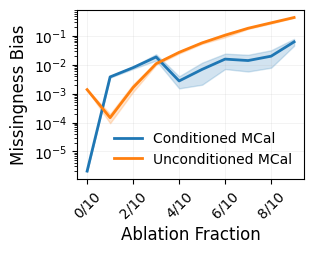

Saved: /home/antonxue/shailesh/MCal/experiments/tabular/figures/physionet_mcal_comparison_fractionwise_kl_argmax_log.pdf

✅ PhysioNet MCal comparison log plot saved to /home/antonxue/shailesh/MCal/experiments/tabular/figures/


In [15]:
# Create comparison plot for MCal_CE vs MCal_CE_Uncond with log scale (Argmax only)
if 'methods_data' in locals() and len(methods_data) >= 2:
    # Ensure output directory exists
    output_dir = 'figures'
    os.makedirs(output_dir, exist_ok=True)
    abs_output_dir = Path(output_dir).absolute()
    print(f"Saving plots to: {abs_output_dir}")
    
    # Get data for both methods
    mcal_ce_data = methods_data['mcal_ce']
    mcal_ce_uncond_data = methods_data['mcal_ce_uncond']
    
    # Plot: KL Divergence (Argmax/One-hot) Comparison - LOG SCALE
    fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_height))
    
    # MCal_CE line and confidence band
    ax.plot(fractions, mcal_ce_data['mean_argmax'], '-', 
            label='Conditioned MCal', linewidth=2, color='#1f77b4')
    ax.fill_between(fractions, 
                    mcal_ce_data['mean_argmax'] - 0.5*mcal_ce_data['std_argmax'], 
                    mcal_ce_data['mean_argmax'] + 0.5*mcal_ce_data['std_argmax'],
                    alpha=0.2, color='#1f77b4')
    
    # MCal_CE_Uncond line and confidence band
    ax.plot(fractions, mcal_ce_uncond_data['mean_argmax'], '-', 
            label='Unconditioned MCal', linewidth=2, color='#ff7f0e')
    ax.fill_between(fractions, 
                    mcal_ce_uncond_data['mean_argmax'] -0.5*mcal_ce_uncond_data['std_argmax'], 
                    mcal_ce_uncond_data['mean_argmax'] + 0.5*mcal_ce_uncond_data['std_argmax'],
                    alpha=0.2, color='#ff7f0e')
    
    ax.set_xlabel('Ablation Fraction')
    ax.set_ylabel('Missingness Bias')
    ax.set_yscale('log')  # LOG SCALE
    ax.legend(loc='best', frameon=False)
    ax.grid(True, alpha=0.2, linewidth=0.5)
    ax.tick_params(axis='both', which='major')
    
    # Set x-axis ticks
    tick_positions = np.arange(0, len(fractions), 2) if len(fractions) > 5 else np.arange(0, len(fractions))
    ax.set_xticks(fractions[tick_positions])
    ax.set_xticklabels([fraction_labels[i] for i in tick_positions], rotation=45)
    
    plt.tight_layout(pad=0.2)
    plt.savefig(f'{output_dir}/physionet_mcal_comparison_fractionwise_kl_argmax_log.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {abs_output_dir}/physionet_mcal_comparison_fractionwise_kl_argmax_log.pdf")
    
    print(f"\n✅ PhysioNet MCal comparison log plot saved to {abs_output_dir}/")
    
else:
    print("❌ No comparison data available to plot")
    if 'methods_data' in locals():
        print(f"Available methods: {list(methods_data.keys())}")
    else:
        print("No methods data loaded")

✅ mcal_ce accuracy data loaded successfully
✅ mcal_ce_uncond accuracy data loaded successfully
✅ baseline accuracy data loaded successfully


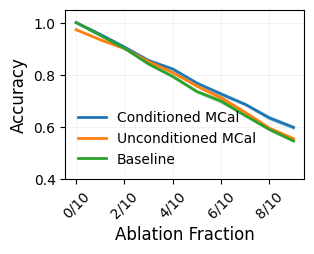

Saved: /home/antonxue/shailesh/MCal/experiments/tabular/figures/physionet_accuracy_comparison_with_baseline.pdf

📊 ACCURACY COMPARISON SUMMARY:
   Conditioned MCal accuracy range: 0.597 to 1.000
   Unconditioned MCal accuracy range: 0.554 to 0.973
   Baseline accuracy range: 0.545 to 1.000

   Average accuracy difference (CE - Uncond): +0.021
   MCal_CE better in 10/10 fractions
   Conditioned MCal vs Baseline: +0.025 average difference
   Unconditioned MCal vs Baseline: +0.004 average difference


In [16]:
# Extract accuracy data and plot fractionwise accuracy comparison including baseline
if 'results' in locals():
    # Extract accuracy data for all three methods
    accuracy_methods_data = {}
    methods_to_plot = ['mcal_ce', 'mcal_ce_uncond', 'baseline']
    
    for method in methods_to_plot:
        if method not in results:
            print(f"⚠️  {method} not found in results")
            continue
            
        method_results = results[method]
        
        # Check for accuracy data in different locations based on method
        if method == 'baseline':
            # Baseline uses 'fraction_wise_results' instead of 'fraction_wise_results_transformed'
            if 'fraction_wise_results' in method_results:
                fraction_data = method_results['fraction_wise_results']
                
                if 'mean_accuracy' in fraction_data and 'std_accuracy' in fraction_data:
                    accuracy_methods_data[method] = {
                        'mean_accuracy': np.array(fraction_data['mean_accuracy']),
                        'std_accuracy': np.array(fraction_data['std_accuracy'])
                    }
                    print(f"✅ {method} accuracy data loaded successfully")
                else:
                    print(f"⚠️  Accuracy data not found for {method}")
        else:
            # MCal methods use 'fraction_wise_results_transformed'
            if 'fraction_wise_results_transformed' in method_results:
                fraction_data = method_results['fraction_wise_results_transformed']
                
                if 'mean_accuracy' in fraction_data and 'std_accuracy' in fraction_data:
                    accuracy_methods_data[method] = {
                        'mean_accuracy': np.array(fraction_data['mean_accuracy']),
                        'std_accuracy': np.array(fraction_data['std_accuracy'])
                    }
                    print(f"✅ {method} accuracy data loaded successfully")
                else:
                    print(f"⚠️  Accuracy data not found for {method}")
    
    if len(accuracy_methods_data) >= 2:
        # Plot: Fractionwise Accuracy Comparison with all available methods
        fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_height))
        
        # Define colors for each method
        colors = {'mcal_ce': '#1f77b4', 'mcal_ce_uncond': '#ff7f0e', 'baseline': '#2ca02c'}
        labels = {'mcal_ce': 'Conditioned MCal', 'mcal_ce_uncond': 'Unconditioned MCal', 'baseline': 'Baseline'}
        
        # Plot each method
        for method in ['mcal_ce', 'mcal_ce_uncond', 'baseline']:
            if method in accuracy_methods_data:
                method_data = accuracy_methods_data[method]
                
                # Plot line and confidence band
                ax.plot(fractions, method_data['mean_accuracy'], '-', 
                        label=labels[method], linewidth=2, color=colors[method])
                ax.fill_between(fractions, 
                                method_data['mean_accuracy'] - 0.5*method_data['std_accuracy'], 
                                method_data['mean_accuracy'] + 0.5*method_data['std_accuracy'],
                                alpha=0.2, color=colors[method])
        
        ax.set_xlabel('Ablation Fraction')
        ax.set_ylabel('Accuracy')
        ax.set_ylim(0.4, 1.05)  # Set reasonable y-axis limits for accuracy
        ax.legend(loc='best', frameon=False)
        ax.grid(True, alpha=0.2, linewidth=0.5)
        ax.tick_params(axis='both', which='major')
        
        # Set x-axis ticks
        tick_positions = np.arange(0, len(fractions), 2) if len(fractions) > 5 else np.arange(0, len(fractions))
        ax.set_xticks(fractions[tick_positions])
        ax.set_xticklabels([fraction_labels[i] for i in tick_positions], rotation=45)
        
        plt.tight_layout(pad=0.2)
        plt.savefig(f'{output_dir}/physionet_accuracy_comparison_with_baseline.pdf', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Saved: {abs_output_dir}/physionet_accuracy_comparison_with_baseline.pdf")
        
        # Print accuracy summary statistics for all methods
        print(f"\n📊 ACCURACY COMPARISON SUMMARY:")
        for method in ['mcal_ce', 'mcal_ce_uncond', 'baseline']:
            if method in accuracy_methods_data:
                method_data = accuracy_methods_data[method]
                print(f"   {labels[method]} accuracy range: {method_data['mean_accuracy'].min():.3f} to {method_data['mean_accuracy'].max():.3f}")
        
        # Calculate pairwise differences if we have MCal methods
        if 'mcal_ce' in accuracy_methods_data and 'mcal_ce_uncond' in accuracy_methods_data:
            acc_diff = accuracy_methods_data['mcal_ce']['mean_accuracy'] - accuracy_methods_data['mcal_ce_uncond']['mean_accuracy']
            print(f"\n   Average accuracy difference (CE - Uncond): {acc_diff.mean():+.3f}")
            print(f"   MCal_CE better in {(acc_diff > 0).sum()}/{len(acc_diff)} fractions")
        
        # Compare with baseline if available
        if 'baseline' in accuracy_methods_data:
            for mcal_method in ['mcal_ce', 'mcal_ce_uncond']:
                if mcal_method in accuracy_methods_data:
                    diff_vs_baseline = accuracy_methods_data[mcal_method]['mean_accuracy'] - accuracy_methods_data['baseline']['mean_accuracy']
                    print(f"   {labels[mcal_method]} vs Baseline: {diff_vs_baseline.mean():+.3f} average difference")
        
    else:
        print("❌ Accuracy data not available for plotting")
        print(f"Available methods with accuracy: {list(accuracy_methods_data.keys())}")
        
else:
    print("❌ Results data not available for accuracy plotting")

## Plot MCal_CE vs MCal_CE_Uncond Fractionwise Accuracy Comparison

## MCal_CE vs MCal_CE_Uncond Comparison Statistics

In [17]:
# Detailed comparison statistics between MCal_CE and MCal_CE_Uncond
if 'methods_data' in locals() and len(methods_data) >= 2:
    print("📊 PHYSIONET: MCAL_CE vs MCAL_CE_UNCOND FRACTIONWISE KL DIVERGENCE COMPARISON")
    print("=" * 80)
    
    mcal_ce_data = methods_data['mcal_ce']
    mcal_ce_uncond_data = methods_data['mcal_ce_uncond']
    
    # Argmax KL Divergence Comparison
    print(f"\n🎯 ARGMAX/ONE-HOT KL DIVERGENCE COMPARISON:")
    print(f"{'Method':<20} {'Min':<12} {'Max':<12} {'Mean':<12} {'Std':<12}")
    print("-" * 70)
    print(f"{'MCal_CE':<20} {mcal_ce_data['mean_argmax'].min():<12.6f} {mcal_ce_data['mean_argmax'].max():<12.6f} "
          f"{mcal_ce_data['mean_argmax'].mean():<12.6f} {mcal_ce_data['mean_argmax'].std():<12.6f}")
    print(f"{'MCal_CE_Uncond':<20} {mcal_ce_uncond_data['mean_argmax'].min():<12.6f} {mcal_ce_uncond_data['mean_argmax'].max():<12.6f} "
          f"{mcal_ce_uncond_data['mean_argmax'].mean():<12.6f} {mcal_ce_uncond_data['mean_argmax'].std():<12.6f}")
    
    # Calculate improvement
    argmax_improvement = ((mcal_ce_data['mean_argmax'].mean() - mcal_ce_uncond_data['mean_argmax'].mean()) 
                         / mcal_ce_data['mean_argmax'].mean()) * 100
    print(f"\n   → MCal_CE_Uncond vs MCal_CE improvement: {argmax_improvement:+.2f}%")
    
    # Fraction-wise comparison - show largest differences
    print(f"\n📈 FRACTION-WISE ANALYSIS:")
    argmax_diff = mcal_ce_data['mean_argmax'] - mcal_ce_uncond_data['mean_argmax']
    
    # Find fractions with largest improvements for MCal_CE_Uncond
    best_argmax_fraction = np.argmax(argmax_diff)  # Largest positive difference (MCal_CE higher)
    
    print(f"   Largest MCal_CE_Uncond advantage (Argmax): Fraction {best_argmax_fraction}/{n_fractions}")
    print(f"      MCal_CE: {mcal_ce_data['mean_argmax'][best_argmax_fraction]:.6f}")
    print(f"      MCal_CE_Uncond: {mcal_ce_uncond_data['mean_argmax'][best_argmax_fraction]:.6f}")
    print(f"      Difference: {argmax_diff[best_argmax_fraction]:.6f}")
    
    # Show trends
    ce_argmax_trend = "increasing" if mcal_ce_data['mean_argmax'][-1] > mcal_ce_data['mean_argmax'][0] else "decreasing"
    uncond_argmax_trend = "increasing" if mcal_ce_uncond_data['mean_argmax'][-1] > mcal_ce_uncond_data['mean_argmax'][0] else "decreasing"
    
    print(f"\n📊 TRENDS ACROSS ABLATION FRACTIONS:")
    print(f"   MCal_CE Argmax KL: {ce_argmax_trend} ({mcal_ce_data['mean_argmax'][0]:.6f} → {mcal_ce_data['mean_argmax'][-1]:.6f})")
    print(f"   MCal_CE_Uncond Argmax KL: {uncond_argmax_trend} ({mcal_ce_uncond_data['mean_argmax'][0]:.6f} → {mcal_ce_uncond_data['mean_argmax'][-1]:.6f})")
    
else:
    print("❌ No comparison data available for detailed statistics")
    if 'methods_data' in locals():
        print(f"Available methods: {list(methods_data.keys())}")
    else:
        print("No methods data loaded")

📊 PHYSIONET: MCAL_CE vs MCAL_CE_UNCOND FRACTIONWISE KL DIVERGENCE COMPARISON

🎯 ARGMAX/ONE-HOT KL DIVERGENCE COMPARISON:
Method               Min          Max          Mean         Std         
----------------------------------------------------------------------
MCal_CE              0.000002     0.063079     0.015364     0.017216    
MCal_CE_Uncond       0.000147     0.441592     0.112302     0.142270    

   → MCal_CE_Uncond vs MCal_CE improvement: -630.94%

📈 FRACTION-WISE ANALYSIS:
   Largest MCal_CE_Uncond advantage (Argmax): Fraction 3/10
      MCal_CE: 0.018829
      MCal_CE_Uncond: 0.010989
      Difference: 0.007840

📊 TRENDS ACROSS ABLATION FRACTIONS:
   MCal_CE Argmax KL: increasing (0.000002 → 0.063079)
   MCal_CE_Uncond Argmax KL: increasing (0.001388 → 0.441592)


## Export Comparison Data

In [18]:
# Export the comparison data in a nice table format
if 'methods_data' in locals() and len(methods_data) >= 2:
    import pandas as pd
    
    # Create comprehensive comparison DataFrame
    comparison_data = []
    
    for i in range(len(fractions)):
        comparison_data.append({
            'Fraction': fraction_labels[i],
            'Ablation_Ratio': fractions[i],
            'MCal_CE_Argmax_Mean': methods_data['mcal_ce']['mean_argmax'][i],
            'MCal_CE_Argmax_Std': methods_data['mcal_ce']['std_argmax'][i],
            'MCal_CE_Uncond_Argmax_Mean': methods_data['mcal_ce_uncond']['mean_argmax'][i],
            'MCal_CE_Uncond_Argmax_Std': methods_data['mcal_ce_uncond']['std_argmax'][i],
            'Argmax_Improvement': ((methods_data['mcal_ce']['mean_argmax'][i] - methods_data['mcal_ce_uncond']['mean_argmax'][i]) / methods_data['mcal_ce']['mean_argmax'][i]) * 100
        })
    
    df_comparison = pd.DataFrame(comparison_data)
    
    print("📋 PHYSIONET: MCAL_CE vs MCAL_CE_UNCOND DETAILED COMPARISON:")
    print(df_comparison.round(6).to_string(index=False))
    
    # Save to CSV
    csv_path = Path("./results/physionet_mcal_comparison_fractionwise_data.csv")
    df_comparison.to_csv(csv_path, index=False)
    print(f"\n✅ Detailed comparison data saved to: {csv_path}")
    
    # Summary statistics
    print(f"\n📊 SUMMARY STATISTICS:")
    print(f"   Average Argmax improvement: {df_comparison['Argmax_Improvement'].mean():+.2f}%")
    print(f"   Best Argmax improvement: {df_comparison['Argmax_Improvement'].max():+.2f}% (Fraction {df_comparison.loc[df_comparison['Argmax_Improvement'].idxmax(), 'Fraction']})")
    
else:
    print("❌ No comparison data available to export")
    if 'methods_data' in locals():
        print(f"Available methods: {list(methods_data.keys())}")
    else:
        print("No methods data loaded")

📋 PHYSIONET: MCAL_CE vs MCAL_CE_UNCOND DETAILED COMPARISON:
Fraction  Ablation_Ratio  MCal_CE_Argmax_Mean  MCal_CE_Argmax_Std  MCal_CE_Uncond_Argmax_Mean  MCal_CE_Uncond_Argmax_Std  Argmax_Improvement
    0/10             0.0             0.000002            0.000000                    0.001388                   0.000050       -67288.458712
    1/10             0.1             0.003831            0.000442                    0.000147                   0.000106           96.152872
    2/10             0.2             0.008036            0.001544                    0.001644                   0.000984           79.543922
    3/10             0.3             0.018829            0.009249                    0.010989                   0.001966           41.636803
    4/10             0.4             0.002771            0.002481                    0.027263                   0.005078         -883.765773
    5/10             0.5             0.006990            0.009874                    0.058149 